OBIETTIVO DEL PROGETTO
In questo notebook verranno eseguite:
-analisi statistiche
-visualizzazioni dei dati
-analisi delle distribuzioni
-studio delle correlazioni
-individuazione degli outlier
-analisi business
-generazione di insight

Questo notebook utilizza il dataset già pulito nella fase SQL.

In [2]:
# Manipolazione dati
import pandas as pd
import numpy as np
# Visualizzazioni
import matplotlib.pyplot as plt
import seaborn as sns
# Analisi statistiche
from scipy import stats
# Caricamento dataset pulito
df = pd.read_csv('C:/Users/rujay/Downloads/Perfume-Ebay-Analysis Capstone Project/Perfume E-Commerce clean/ebay_perfume_clean.csv')

PRIMO CONTROLLO DEL DATASET

In [3]:
# Visualizzare le prime righe
df.head()
# Informazioni sul dataset
df.info()
# Statistiche descrittive delle colonne numeriche
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1990 entries, 0 to 1989
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   category          1990 non-null   object 
 1   brand             1883 non-null   object 
 2   title             1990 non-null   object 
 3   type              1977 non-null   object 
 4   price             1990 non-null   float64
 5   available         1750 non-null   float64
 6   available_status  1990 non-null   object 
 7   sold              1990 non-null   int64  
 8   country           1990 non-null   object 
 9   last_updated      1866 non-null   object 
dtypes: float64(2), int64(1), object(7)
memory usage: 155.6+ KB


,price,available,sold
count,1990.000000,1750.000000,1990.000000
mean,43.186171,20.787429,628.518090
std,32.662594,56.904215,2463.113298
min,1.990000,2.000000,0.000000
25%,21.982500,5.000000,14.000000
50%,33.995000,10.000000,50.000000
75%,53.987500,10.000000,280.000000
max,299.990000,842.000000,54052.000000


COMPRENDERE LA STRUTTURA DEL DATASET

In [4]:
# Numero righe e colonne
print(df.shape)
# Nomi colonne
print(df.columns)
# Controllo valori mancanti
df.isnull().sum()

(1990, 10)
Index(['category', 'brand', 'title', 'type', 'price', 'available',
       'available_status', 'sold', 'country', 'last_updated'],
      dtype='object')


category              0
brand               107
title                 0
type                 13
price                 0
available           240
available_status      0
sold                  0
country               0
last_updated        124
dtype: int64

DISTRIBUZIONE DELLE CATEGORIE
Obiettivo:capire quanti prodotti appartengono alle categorie uomo e donna.

In [5]:
# Conteggio prodotti per categoria
df['category'].value_counts()

category
women    996
men      994
Name: count, dtype: int64

GRAFICO CATEGORIE

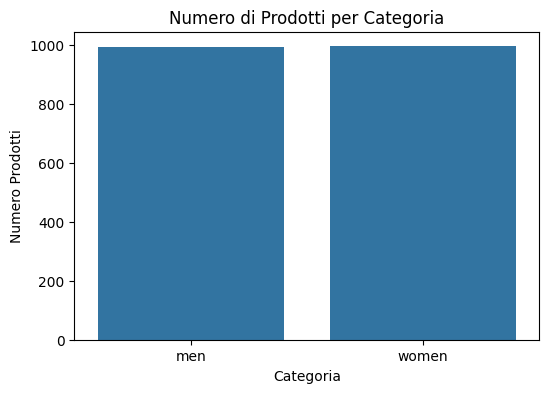

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='category')

plt.title('Numero di Prodotti per Categoria')
plt.xlabel('Categoria')
plt.ylabel('Numero Prodotti')

plt.show()

ANALISI DELLA DISTRIBUZIONE PREZZI
Obiettivo

Analizzare come sono distribuiti i prezzi.

In [7]:
# Statistiche dei prezzi
df['price'].describe()

count    1990.000000
mean       43.186171
std        32.662594
min         1.990000
25%        21.982500
50%        33.995000
75%        53.987500
max       299.990000
Name: price, dtype: float64

ISTOGRAMMA DISTRIBUZIONE PREZZI

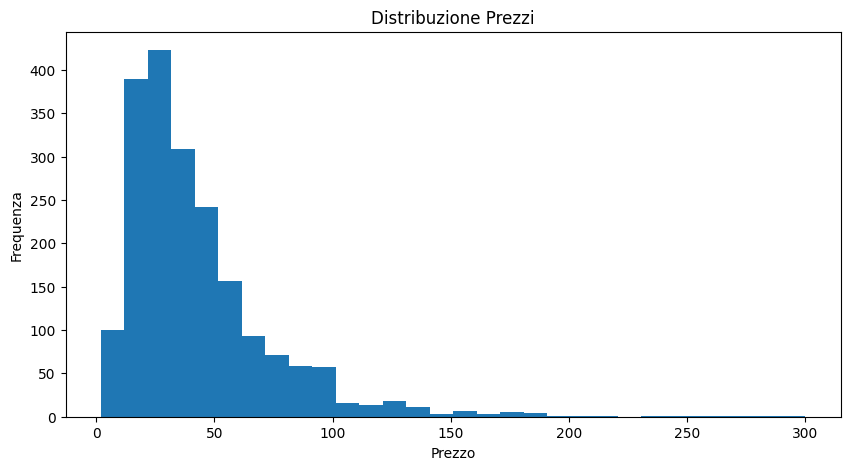

In [8]:
plt.figure(figsize=(10,5))

plt.hist(df['price'], bins=30)

plt.title('Distribuzione Prezzi')
plt.xlabel('Prezzo')
plt.ylabel('Frequenza')

plt.show()

Possibili insight:
-La maggior parte dei prodotti può essere concentrata nelle fasce prezzo basse.
-Alcuni prodotti molto costosi possono creare una distribuzione asimmetrica.
-Potrebbero essere presenti outlier.

BOXPLOT PREZZI
Obiettivo:individuare prezzi anomali

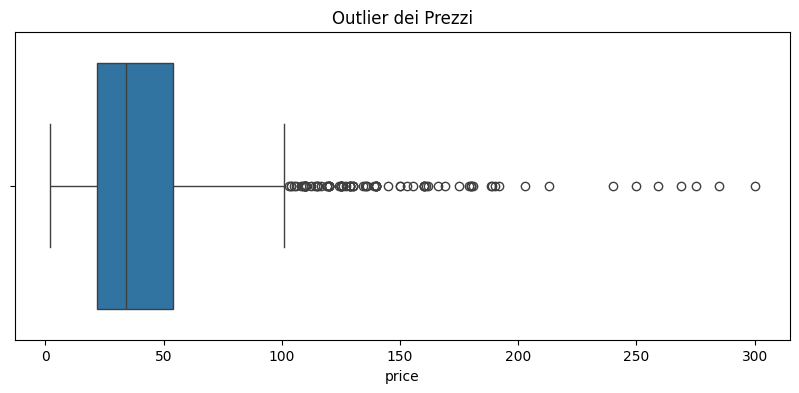

In [9]:
plt.figure(figsize=(10,4))

sns.boxplot(x=df['price'])

plt.title('Outlier dei Prezzi')

plt.show()

La maggior parte dei profumi si concentra in una fascia di prezzo medio-bassa, mentre sono presenti numerosi outlier ad alto prezzo che rappresentano prodotti premium o luxury. Questo suggerisce una distribuzione fortemente asimmetrica dei prezzi nel mercato ecommerce dei profumi.

RICERCA OUTLIER CON IQR
Obiettivo:trovare prezzi estremamente alti o bassi.

In [10]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print('Limite Inferiore:', lower_bound)
print('Limite Superiore:', upper_bound)

Limite Inferiore: -26.02499999999999
Limite Superiore: 101.99499999999999


L’analisi IQR mostra che i prezzi superiori a circa 102 vengono classificati come outlier statistici. Tuttavia, nel contesto ecommerce dei profumi, questi valori probabilmente rappresentano prodotti premium reali piuttosto che errori nei dati.
Mentre non sono presenti outlier bassi significativi nel dataset.

VISUALIZZARE GLI OUTLIER

In [ ]:
outliers = df[
    (df['price'] < lower_bound) |
    (df['price'] > upper_bound)
]

outliers[['brand', 'title', 'price']].head(20)

,brand,title,price
0,Paco Rabanne,1 Million Lucky by Paco Rabanne 3.4 oz EDT Col...,108.98
28,NaN,A-v-entus Eau de Parfum 3.3 oz 100ML Millesime...,109.99
30,NaN,A-ventus Eau De Parfum For Men Millesime EDP C...,109.99
31,NaN,A v-entus Eau de Parfum 3.3 oz 100ML Millesime...,109.99
44,Giorgio Armani,Acqua Di Gio Absolu Giorgio Armani EDP 125 ML ...,192.00
58,Giorgio Armani,Acqua Di Gio Profumo by Giorgio Armani 4.2oz C...,138.99
59,Giorgio Armani,Acqua Di Gio Profumo by Giorgio Armani 4.2oz C...,119.99
77,Amouage,Amouage Interlude by Amouage 3.4 oz EDP Cologn...,166.18
78,Mfk,AQUA MEDIA COLOGNE FORTE 70 ML / 2.4 oz NEW BOX,119.99
89,Armaf,Armaf Club de Nuit Precieux 1 Extrait de Parfu...,125.00


In [19]:
# 1. Correggere varianti strane del nome prodotto Aventus

df['title'] = df['title'].str.replace('A-v-entus', 'Aventus', case=False, regex=False)
df['title'] = df['title'].str.replace('A-ventus', 'Aventus', case=False, regex=False)
df['title'] = df['title'].str.replace('A ventus', 'Aventus', case=False, regex=False)


# 2. Se nel titolo c'è Aventus, il brand deve essere Creed

df.loc[
    df['title'].str.contains('aventus', case=False, na=False),
    'brand'
] = 'Creed'


# 3. Verifica: tutti i prodotti Aventus devono avere brand Creed

df[df['title'].str.contains('aventus', case=False, na=False)][
    ['brand', 'title', 'price']
].head(30)

,brand,title,price
28,Creed,Aventus Eau de Parfum 3.3 oz 100ML Millesime E...,109.99
30,Creed,Aventus Eau De Parfum For Men Millesime EDP Co...,109.99
122,Creed,"Aventus by Creed, 3.3 oz Millesime EDP Spray f...",259.09
123,Creed,"Aventus Cologne by Creed, 3.3 oz Millesime EDP...",212.89
124,Creed,Aventus Cologne for Men by Creed 2ml Vial Spra...,11.99
254,Creed,Creed Aventus by Creed EDP Cologne for Men 1.7...,188.30
255,Creed,Creed Aventus Eau De Parfum Travel Size Spray ...,38.99
256,Creed,Creed Aventus For Men Travel Size Pack of 2 Ro...,9.96
257,Creed,Creed Aventus Men Eau De Parfum Vial Spray SIZ...,15.99
643,Creed,New In Box Eau De Parfum Aventus 3.3 /OZ 100 M...,189.99


DISTRIBUZIONE DELLE VENDITE
Obiettivo:analizzare la distribuzione delle vendite.

In [20]:
# Statistiche vendite
df['sold'].describe()

count     1990.000000
mean       628.518090
std       2463.113298
min          0.000000
25%         14.000000
50%         50.000000
75%        280.000000
max      54052.000000
Name: sold, dtype: float64

ISTOGRAMMA VENDITE

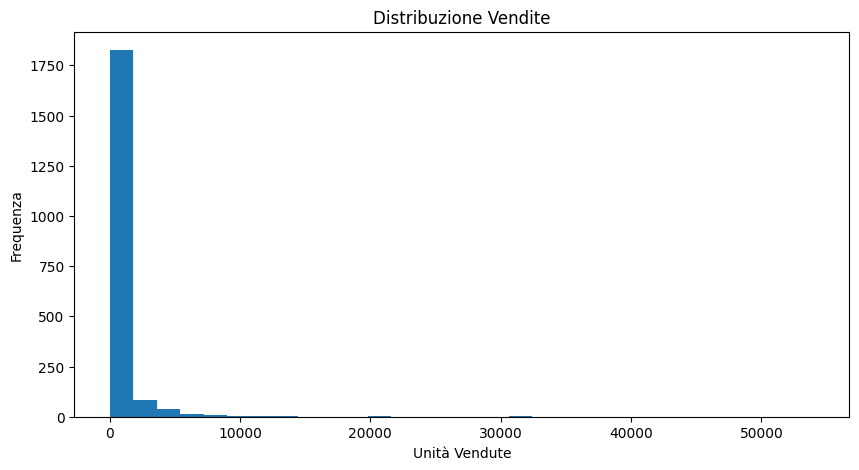

In [21]:
plt.figure(figsize=(10,5))

plt.hist(df['sold'], bins=30)

plt.title('Distribuzione Vendite')
plt.xlabel('Unità Vendute')
plt.ylabel('Frequenza')

plt.show()

TOP BRAND PER VENDITE
Obiettivo:individuare i brand migliori

In [22]:
brand_sales = (
    df.groupby('brand')['sold']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

brand_sales

brand
Calvin Klein       145672
Versace            128077
Davidoff            60289
Burberry            38361
Azzaro              38305
Liz Claiborne       29170
Dolce & Gabbana     28570
Armaf               27120
Kenneth Cole        24636
Paco Rabanne        23506
Name: sold, dtype: int64

GRAFICO TOP BRAND

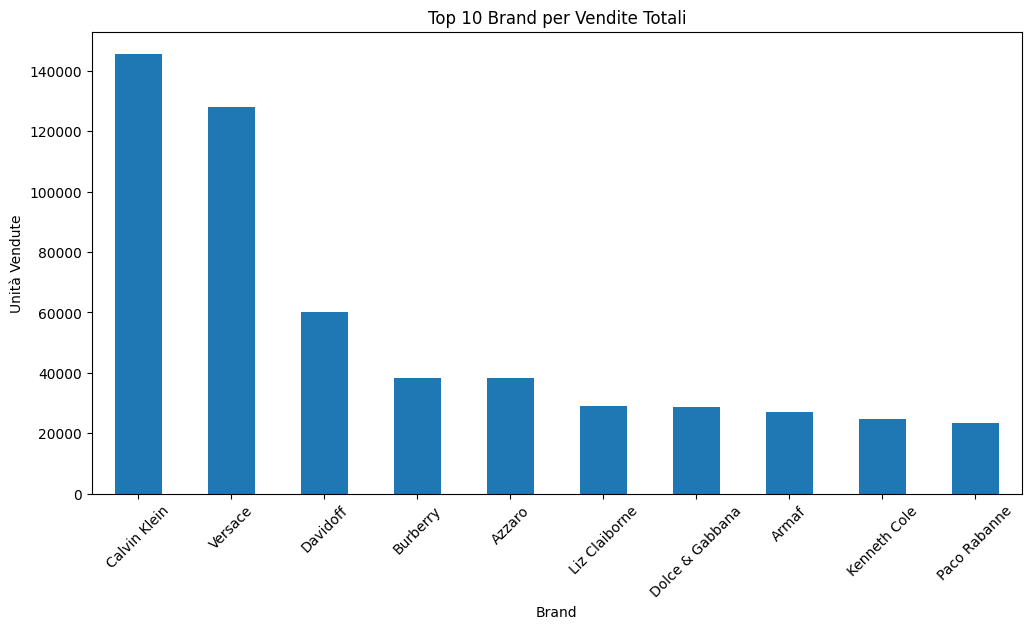

In [23]:
plt.figure(figsize=(12,6))

brand_sales.plot(kind='bar')

plt.title('Top 10 Brand per Vendite Totali')
plt.xlabel('Brand')
plt.ylabel('Unità Vendute')

plt.xticks(rotation=45)

plt.show()

PREZZO MEDIO PER CATEGORIA
Obiettivo:confrontare il prezzo medio uomo vs donna

In [24]:
avg_price = df.groupby('category')['price'].mean()

avg_price

category
men      46.548652
women    39.830442
Name: price, dtype: float64

GRAFICO PREZZO MEDIO

<function matplotlib.pyplot.show(close=None, block=None)>

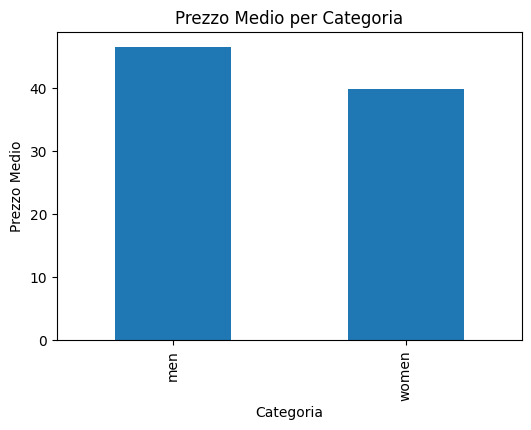

In [25]:
plt.figure(figsize=(6,4))

avg_price.plot(kind='bar')

plt.title('Prezzo Medio per Categoria')
plt.xlabel('Categoria')
plt.ylabel('Prezzo Medio')

plt.show

ANALISI TIPOLOGIA PROFUMI
Obiettivo:capire quali tipi di profumo performano meglio

In [26]:
type_sales = (
    df.groupby('type')['sold']
      .sum()
      .sort_values(ascending=False)
)

print(type_sales)

type
Eau de Toilette    742951
Eau de Parfum      334734
Cologne             63789
Other               28107
Parfum              21857
Lotion               2307
Body Mist             864
Deodorant             735
Perfume Oil           520
Name: sold, dtype: int64


GRAFICO VENDITE PER TIPOLOGIA

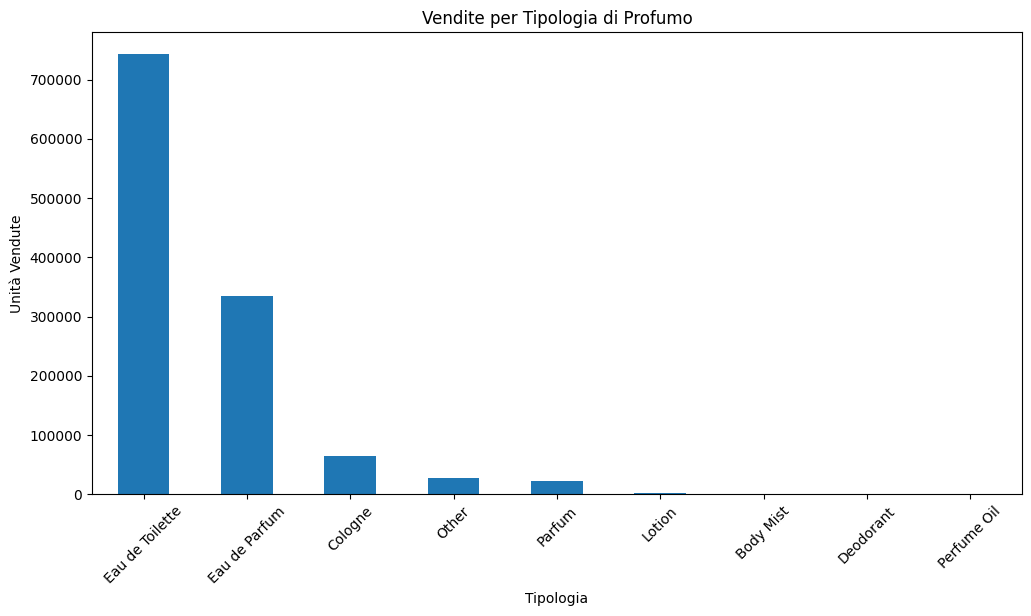

In [27]:
plt.figure(figsize=(12,6))

type_sales.plot(kind='bar')

plt.title('Vendite per Tipologia di Profumo')
plt.xlabel('Tipologia')
plt.ylabel('Unità Vendute')

plt.xticks(rotation=45)

plt.show()

ANALISI PAESI
Obiettivo:capire la distribuzione geografica dei venditori

In [28]:
country_count = df['country'].value_counts().head(10)
country_count

country
United States    1827
Hong Kong         100
China              24
Canada             15
Taiwan             12
India               4
Poland              2
Israel              1
Brazil              1
Portugal            1
Name: count, dtype: int64

GRAFICO TOP PAESI

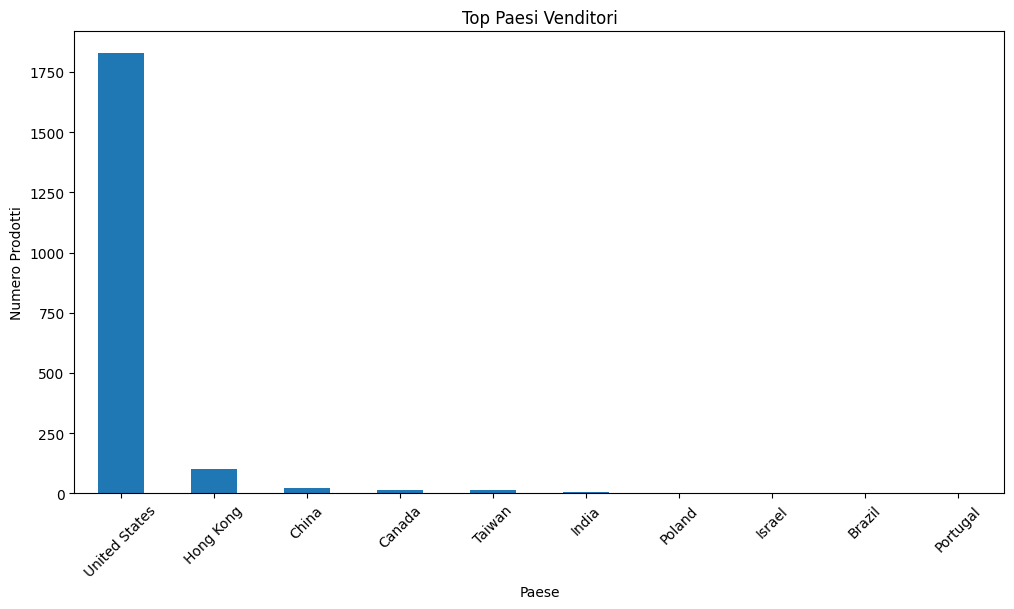

In [29]:
plt.figure(figsize=(12,6))

country_count.plot(kind='bar')

plt.title('Top Paesi Venditori')
plt.xlabel('Paese')
plt.ylabel('Numero Prodotti')

plt.xticks(rotation=45)

plt.show()

ANALISI CORRELAZIONE
Obiettivo:studiare la relazione tra prezzo e vendite

In [30]:
correlation = df[['price', 'sold']].corr()
print(correlation)

          price      sold
price  1.000000 -0.089527
sold  -0.089527  1.000000


Nel dataset non emerge una relazione lineare significativa tra prezzo e vendite.

HEATMAP CORRELAZIONE

<function matplotlib.pyplot.show(close=None, block=None)>

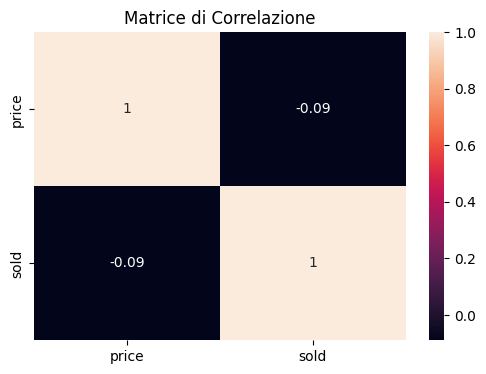

In [31]:
plt.figure(figsize=(6,4))

sns.heatmap(correlation, annot=True)

plt.title('Matrice di Correlazione')

plt.show

La matrice di correlazione mostra che tra price e sold esiste una correlazione negativa molto debole (-0.09) Questo suggerisce che il prezzo, nel dataset analizzato, non influisce significativamente sul volume delle vendite e che altri fattori potrebbero avere un impatto maggiore sul comportamento di acquisto

SCATTERPLOT PREZZO VS VENDITE
Obiettivo:visualizzare la relazione tra prezzo e vendite

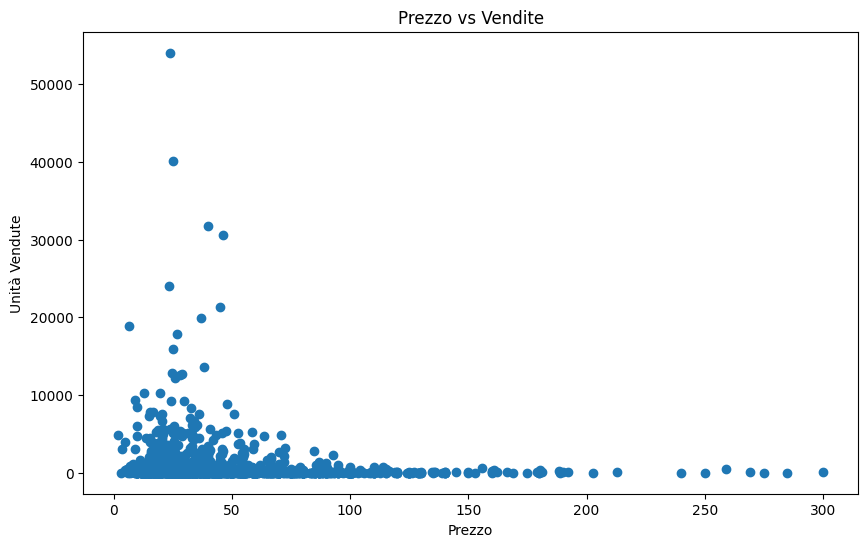

In [32]:
plt.figure(figsize=(10,6))

plt.scatter(df['price'], df['sold'])

plt.title('Prezzo vs Vendite')
plt.xlabel('Prezzo')
plt.ylabel('Unità Vendute')

plt.show()

ANALISI FASCE DI PREZZO
Obiettivo:confrontare prodotti economici, medi e premium

In [33]:
# Creazione segmenti prezzo
def price_segment(price):
    if price < 30:
        return 'Prezzo Basso'
    elif price <= 80:
        return 'Prezzo Medio'
    else:
        return 'Prezzo Alto'

df['price_segment'] = df['price'].apply(price_segment)

ANALISI SEGMENTI PREZZO

In [34]:
segment_analysis = (
    df.groupby('price_segment')
      .agg({
          'price':'mean',
          'sold':'mean'
      })
)

segment_analysis

,price,sold
price_segment,,
Prezzo Alto,116.202609,125.270531
Prezzo Basso,20.220654,843.121560
Prezzo Medio,48.577530,537.451153


GRAFICO VENDITE PER FASCIA PREZZO

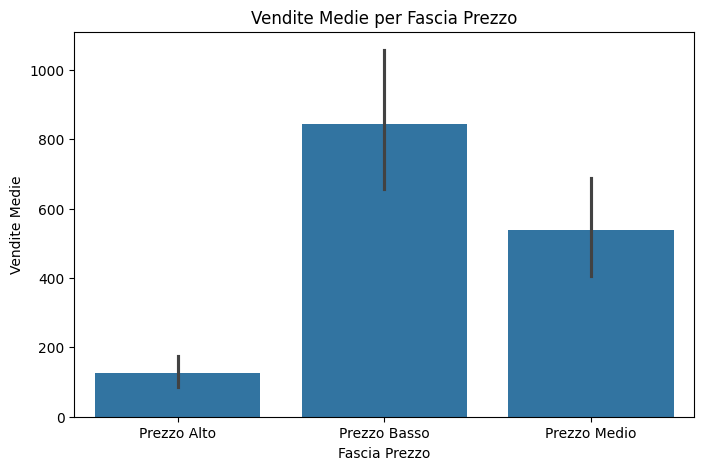

In [35]:
plt.figure(figsize=(8,5))

sns.barplot(data=df, x='price_segment', y='sold')

plt.title('Vendite Medie per Fascia Prezzo')
plt.xlabel('Fascia Prezzo')
plt.ylabel('Vendite Medie')

plt.show()

STIMA REVENUE
Obiettivo:stimare il valore economico dei prodotti.
Revenue = prezzo * unità vendute

In [36]:
# Creazione colonna revenue stimata
df['estimated_revenue'] = df['price'] * df['sold']

TOP PRODOTTI PER REVENUE STIMATA

In [37]:
top_revenue_products = (
    df[['brand', 'title', 'estimated_revenue']]
      .sort_values(by='estimated_revenue', ascending=False)
      .head(10)
)

print(top_revenue_products)

             brand                                              title  \
216         Azzaro  Chrome by Azzaro 6.7 / 6.8 oz EDT Cologne for ...   
223   Calvin Klein  Ck One by Calvin Klein Cologne Perfume Unisex ...   
908        Versace  Versace Eros by Gianni Versace 3.4 oz EDT Colo...   
249       Davidoff  Cool Water by Davidoff 4.2 oz EDT Cologne for ...   
922        Versace  Versace Pour Homme Signature by Versace 3.4 oz...   
923        Versace  Versace Pour Homme Signature by Versace 3.4 oz...   
653   Calvin Klein  OBSESSION by Calvin Klein 4.0 oz 4 MEN edt Col...   
251       Davidoff  Cool Water by Davidoff Cologne for Men 6.7 / 6...   
1298  Calvin Klein  Escape by Calvin Klein EDP Perfume for Women 3...   
1945  Paco Rabanne  1 Million by Paco Rabanne 3.4 oz EDT Cologne f...   

      estimated_revenue  
216          1420246.15  
223          1291302.28  
908          1261424.86  
249          1012479.90  
922           957671.40  
923           733875.12  
653           

GRAFICO TOP REVENUE

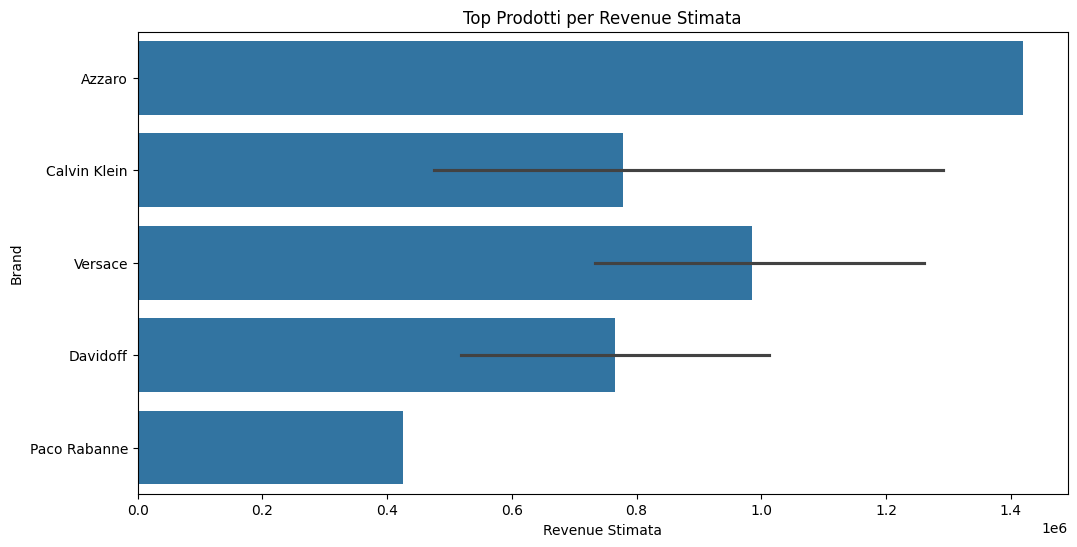

In [38]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_revenue_products,
    x='estimated_revenue',
    y='brand'
)

plt.title('Top Prodotti per Revenue Stimata')
plt.xlabel('Revenue Stimata')
plt.ylabel('Brand')

plt.show()

TEST STATISTICO — PREZZI UOMO VS DONNA
Obiettivo:verificare se la differenza di prezzo tra uomo e donna è statisticamente significativa.
T-Test indipendente

In [39]:
men_prices = df[df['category'] == 'men']['price']
women_prices = df[df['category'] == 'women']['price']


t_stat, p_value = stats.ttest_ind(men_prices, women_prices)

print('T-statistic:', t_stat)
print('P-value:', p_value)

T-statistic: 4.611052955410871
P-value: 4.261216093715599e-06


INTERPRETAZIONE TEST

In [40]:
if p_value < 0.05:
    print('Esiste una differenza statisticamente significativa nei prezzi.')
else:
    print('Non esiste una differenza statisticamente significativa nei prezzi.')

Esiste una differenza statisticamente significativa nei prezzi.


KPI SUMMARY FINALE
Obiettivo:creare un riepilogo finale del progetto

In [41]:
summary = {
    'Totale Prodotti': len(df),
    'Totale Brand': df['brand'].nunique(),
    'Totale Paesi': df['country'].nunique(),
    'Prezzo Medio': round(df['price'].mean(), 2),
    'Totale Unità Vendute': int(df['sold'].sum()),
    'Revenue Stimata': round(df['estimated_revenue'].sum(), 2)
}

summary

{'Totale Prodotti': 1990,
 'Totale Brand': 368,
 'Totale Paesi': 13,
 'Prezzo Medio': np.float64(43.19),
 'Totale Unità Vendute': 1250751,
 'Revenue Stimata': np.float64(39689155.22)}

L’analisi del marketplace eBay ha mostrato che il segmento profumi uomo domina il mercato con oltre 761 mila unità vendute rispetto alle circa 489 mila della categoria donna, indicando una domanda significativamente più alta per le fragranze maschili. Brand come Calvin Klein, Versace, Davidoff e Paco Rabanne emergono come leader del mercato, mentre la categoria Eau de Toilette risulta la tipologia più performante con oltre 742 mila unità vendute, superando nettamente Eau de Parfum e Cologne. Inoltre, i prodotti nella fascia prezzo bassa (sotto i 30$) registrano mediamente il volume di vendite più alto, suggerendo che il mercato e-commerce dei profumi su eBay è fortemente guidato da prodotti accessibili ad alta rotazione.

In [42]:
# Esportazione dataset finale per Power BI

df.to_csv('C:/Users/rujay/Downloads/Perfume-Ebay-Analysis Capstone Project/Perfume E-commerce clean/ebay_perfume_final.csv', index=False)
           